# Regression with PyTorch v2 (oracle) — Income, deeper MLP

**Version:** 2nd Version (deeper MLP). **Role:** reference oracle for the v2 scratch twin.
Same data/features/splits/seed as v1 (z-scored target); only model + training change: `FC(13→64)→BN→ReLU→Dropout(0.2)→FC(64→64)→BN→(+residual)→ReLU→Dropout(0.2)→FC(64→1)`, 100 epochs, Adam + cosine schedule + weight decay. Weights → `./weights_v2/`.

In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
os.makedirs("weights_v2", exist_ok=True)
print("torch:", torch.__version__)

# ---- 1. LOAD DATA (identical to v1) ----
df = pd.read_csv("marketing_campaign.csv", sep="\t")
df = df.drop(columns=["ID", "Z_CostContact", "Z_Revenue"])
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")
ref_date = df["Dt_Customer"].max()
df["Customer_Tenure_Days"] = (ref_date - df["Dt_Customer"]).dt.days
df["Age"] = 2014 - df["Year_Birth"]
df = df[~df["Year_Birth"].isin([1893, 1899, 1900])].copy()
df["Marital_Status"] = df["Marital_Status"].replace({"Absurd": "Single", "YOLO": "Single", "Alone": "Single"})
df = df.dropna(subset=["Income"]).copy()
print("cleaned:", df.shape, "| Income median:", round(df["Income"].median()))

REG_FEATURES = [
    "NumCatalogPurchases", "MntMeatProducts", "MntWines", "NumWebVisitsMonth",
    "MntSweetProducts", "MntFruits", "NumWebPurchases", "MntGoldProds",
    "NumStorePurchases", "MntFishProducts", "Kidhome", "Age", "NumDealsPurchases",
]
X_full = df[REG_FEATURES].values
y_full = df["Income"].astype(float).values
print(f"features: {len(REG_FEATURES)} dims (all numeric)")

torch: 2.14.1
cleaned: (2213, 28) | Income median: 51373
features: 13 dims (all numeric)


## 2–3. Dataset Class + DataLoader (same split + feature/target scalers as v1)

In [2]:
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(np.asarray(X, dtype=np.float32))
        self.y = torch.from_numpy(np.asarray(y, dtype=np.float32)).view(-1, 1)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, i):
        return self.X[i], self.y[i]

X_temp, X_test, y_temp, y_test = train_test_split(X_full, y_full, test_size=0.20, random_state=SEED)
scaler = StandardScaler().fit(X_temp)
Xtr, Xte = scaler.transform(X_temp), scaler.transform(X_test)
y_scaler = StandardScaler().fit(y_temp.reshape(-1, 1))
ytr_z = y_scaler.transform(y_temp.reshape(-1, 1)).ravel()
yte_z = y_scaler.transform(y_test.reshape(-1, 1)).ravel()
print(f"train {Xtr.shape} test {Xte.shape} | y mean {y_full.mean():.0f} std {y_full.std():.0f}")
print(f"y scaler: mean {y_scaler.mean_[0]:.0f} scale {y_scaler.scale_[0]:.0f} (train on z, metrics in $)")
train_ds, test_ds = TabularDataset(Xtr, ytr_z), TabularDataset(Xte, yte_z)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,
                            generator=torch.Generator().manual_seed(SEED))
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

train (1770, 13) test (443, 13) | y mean 52237 std 25173
y scaler: mean 52026 scale 26009 (train on z, metrics in $)


## 4. Model Class v2 — ResNet-style block, He init

In [3]:
class RegDeepMLP(nn.Module):
    def __init__(self, in_dim=13, h=64, p=0.2):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, h)
        self.bn1 = nn.BatchNorm1d(h)
        self.fc2 = nn.Linear(h, h)
        self.bn2 = nn.BatchNorm1d(h)
        self.fc3 = nn.Linear(h, 1)
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(p)
        for fc, nl in ((self.fc1, "relu"), (self.fc2, "relu"), (self.fc3, "linear")):
            nn.init.kaiming_normal_(fc.weight, nonlinearity=nl)
            nn.init.zeros_(fc.bias)
    def forward(self, x):
        d1 = self.drop(self.relu(self.bn1(self.fc1(x))))
        s = self.bn2(self.fc2(d1)) + d1
        d2 = self.drop(self.relu(s))
        return self.fc3(d2)

device = torch.device("cpu")
model = RegDeepMLP(in_dim=len(REG_FEATURES)).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"params: {n_params} (expect ~5393)")
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

RegDeepMLP(
  (fc1): Linear(in_features=13, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
  (drop): Dropout(p=0.2, inplace=False)
)
params: 5377 (expect ~5393)


## 5. Training Loop v2 (100 epochs) — logs z-MSE + val RMSE ($), saves to weights_v2

epoch 001 | train_z 0.6533 | val_z 0.3939 | val_RMSE_$ 16324 | lr 1.00e-03


epoch 010 | train_z 0.4795 | val_z 0.1826 | val_RMSE_$ 11113 | lr 9.76e-04


epoch 020 | train_z 0.4730 | val_z 0.1749 | val_RMSE_$ 10877 | lr 9.05e-04


epoch 030 | train_z 0.4665 | val_z 0.1689 | val_RMSE_$ 10690 | lr 7.94e-04


epoch 040 | train_z 0.4648 | val_z 0.1690 | val_RMSE_$ 10692 | lr 6.55e-04


...

epoch 060 | train_z 0.4607 | val_z 0.1627 | val_RMSE_$ 10492 | lr 3.45e-04


epoch 070 | train_z 0.4575 | val_z 0.1600 | val_RMSE_$ 10402 | lr 2.06e-04


epoch 080 | train_z 0.4581 | val_z 0.1616 | val_RMSE_$ 10457 | lr 9.55e-05


epoch 090 | train_z 0.4576 | val_z 0.1625 | val_RMSE_$ 10485 | lr 2.45e-05


epoch 100 | train_z 0.4570 | val_z 0.1588 | val_RMSE_$ 10366 | lr 0.00e+00
saved to weights_v2/


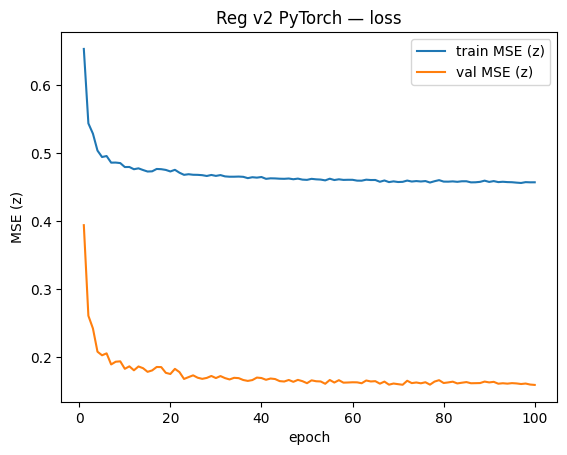

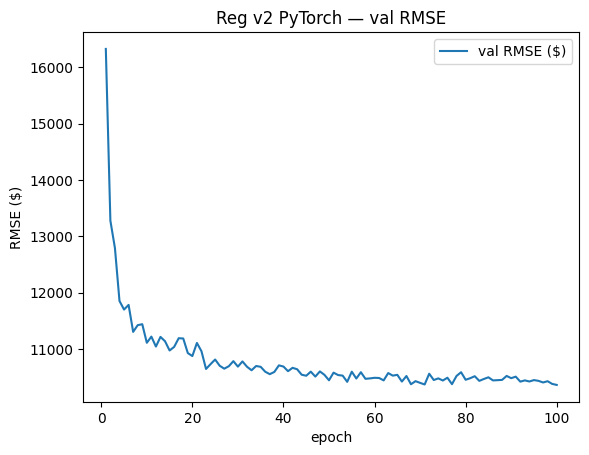

In [4]:
EPOCHS = 100
history = {"epoch": [], "train_loss_z": [], "val_loss_z": [], "val_rmse": [], "lr": []}
mse = nn.MSELoss()

def evaluate(m):
    m.eval()
    with torch.no_grad():
        Xt = torch.from_numpy(Xte.astype(np.float32)).to(device)
        pred_z = m(Xt).cpu().numpy().ravel()
        pred = y_scaler.inverse_transform(pred_z.reshape(-1, 1)).ravel()
        loss_z = float(np.mean((pred_z - yte_z) ** 2))
        rmse = float(np.sqrt(np.mean((pred - y_test) ** 2)))
        return loss_z, rmse

for epoch in range(1, EPOCHS + 1):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
    scheduler.step()
    model.eval()
    with torch.no_grad():
        Xt = torch.from_numpy(Xtr.astype(np.float32)).to(device)
        yt = torch.from_numpy(ytr_z.astype(np.float32)).view(-1, 1).to(device)
        tr = mse(model(Xt), yt).item()
    vl_z, vr = evaluate(model)
    lr = optimizer.param_groups[0]["lr"]
    history["epoch"].append(epoch)
    history["train_loss_z"].append(tr)
    history["val_loss_z"].append(vl_z)
    history["val_rmse"].append(vr)
    history["lr"].append(lr)
    if epoch == 1 or epoch % 10 == 0 or epoch == EPOCHS:
        print(f"epoch {epoch:03d} | train_z {tr:.4f} | val_z {vl_z:.4f} | val_RMSE_$ {vr:.0f} | lr {lr:.2e}")

torch.save(model.state_dict(), "weights_v2/regression_mlp.pt")
np.savez("weights_v2/regression_scaler.npz", mean=scaler.mean_, scale=scaler.scale_,
         columns=np.array(REG_FEATURES), y_mean=y_scaler.mean_, y_scale=y_scaler.scale_)
pd.DataFrame(history).to_csv("weights_v2/regression_pytorch_history.csv", index=False)
print("saved to weights_v2/")
plt.figure(); plt.plot(history["epoch"], history["train_loss_z"], label="train MSE (z)")
plt.plot(history["epoch"], history["val_loss_z"], label="val MSE (z)")
plt.xlabel("epoch"); plt.ylabel("MSE (z)"); plt.legend(); plt.title("Reg v2 PyTorch — loss"); plt.show()
plt.figure(); plt.plot(history["epoch"], history["val_rmse"], label="val RMSE ($)")
plt.xlabel("epoch"); plt.ylabel("RMSE ($)"); plt.legend(); plt.title("Reg v2 PyTorch — val RMSE"); plt.show()

## 6. Inference Loop — fresh instance loads `./weights_v2/regression_mlp.pt`, metrics in raw $

In [5]:
fresh = RegDeepMLP(in_dim=len(REG_FEATURES)).to(device)
fresh.load_state_dict(torch.load("weights_v2/regression_mlp.pt", map_location=device))
fresh.eval()
with torch.no_grad():
    Xt = torch.from_numpy(Xte.astype(np.float32)).to(device)
    pred = y_scaler.inverse_transform(fresh(Xt).cpu().numpy()).ravel()
test_mse = float(mean_squared_error(y_test, pred))
metrics = {
    "test_loss_MSE_raw": round(test_mse, 1),
    "rmse": round(float(np.sqrt(test_mse)), 1),
    "mae": round(float(mean_absolute_error(y_test, pred)), 1),
    "r2": round(float(r2_score(y_test, pred)), 4),
    "n_test": int(len(y_test)), "seed": SEED,
}
print(json.dumps(metrics, indent=2))
with open("weights_v2/regression_pytorch_test_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
for i in range(5):
    print(f"  pred={pred[i]:.0f} true={y_test[i]:.0f}")

{
  "test_loss_MSE_raw": 107448373.9,
  "rmse": 10365.7,
  "mae": 6592.4,
  "r2": 0.7673,
  "n_test": 443,
  "seed": 42
}
  pred=68509 true=62450
  pred=40224 true=37235
  pred=72891 true=65492
  pred=40083 true=42618
  pred=41236 true=26997
